In [30]:
# Import statements
import numpy as np
import os
import csv
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import datasets
from nilearn.connectome import ConnectivityMeasure
from brainspace.utils.parcellation import reduce_by_labels
from brainspace.gradient import GradientMaps
from brainspace.datasets import load_fsa5
from brainspace.plotting import plot_hemispheres
from brainspace.utils.parcellation import map_to_labels
import seaborn as sns
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import MultiComparison, pairwise_tukeyhsd

Eigenvalues CCI
[0.7339795  0.79465098 0.8454694  0.87923131 0.91013941 0.93443953
 0.95539752 0.97160704 0.98614598 1.        ]
Eigenvalues SHM
[0.66293046 0.77167719 0.83900454 0.8824572  0.91085501 0.93435493
 0.95551203 0.97353477 0.98737432 1.        ]


/Users/rachelfox/opt/anaconda3/lib/python3.9/site-packages/nilearn/connectome/connectivity_matrices.py:509: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  covariances_std = [
/Users/rachelfox/opt/anaconda3/lib/python3.9/site-packages/nilearn/connectome/connectivity_matrices.py:509: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  covariances_

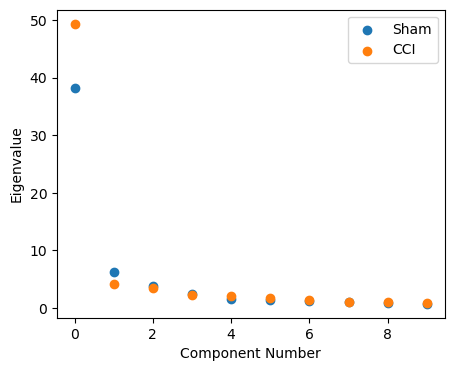

In [27]:
# Compute mean time series for CCI/Sham then produce gradient
folder_path = '/Users/rachelfox/dFC_Toolboxes/Leida/CSVs_with_regions_stim_pattern_CIMT/Restingstate'

# List to store dataframes
dfs_SHM = []
dfs_CCI = []

day = "07d" # change for 07d, 21d and 49d

# Loop through files in the folder and load time series
for file_name in os.listdir(folder_path):
    if 'SHM' in file_name and day in file_name and file_name.endswith('.csv'):
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path, header=None)
        dfs_SHM.append(df)

    elif 'CCI' in file_name and day in file_name and file_name.endswith('.csv'):
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path, header=None)
        dfs_CCI.append(df)

# generate mean time series as numpy array
mean_df_SHM = pd.concat(dfs_SHM).groupby(level=0).mean()
mean_df_CCI = pd.concat(dfs_CCI).groupby(level=0).mean()

mean_SHM_ts = (mean_df_SHM.T).values
mean_CCI_ts = (mean_df_CCI.T).values

# map time series to labels
lbls = pd.read_csv('/Users/rachelfox/dFC_Toolboxes/Leida/CSVs_with_regions_stim_pattern_CIMT/rois_labels.txt', header=None, delimiter='\s+')
labels = lbls[1].to_numpy()
seed_ts_SHM = reduce_by_labels(mean_SHM_ts, labels, axis=1, red_op='mean')
seed_ts_CCI = reduce_by_labels(mean_CCI_ts, labels, axis=1, red_op='mean')

# compute correlation matrix for each group
correlation_measure = ConnectivityMeasure(kind='correlation')
correlation_matrix_SHM = correlation_measure.fit_transform([seed_ts_SHM.T])[0]
correlation_matrix_CCI = correlation_measure.fit_transform([seed_ts_CCI.T])[0]

# get the gradients for each group
gm_SHM = GradientMaps(n_components=10, kernel='pearson', approach='dm', random_state=0)
gm_SHM.fit(correlation_matrix_SHM)

gm_CCI = GradientMaps(n_components=10, kernel='pearson', approach='dm', random_state=0)
gm_CCI.fit(correlation_matrix_CCI)

# graph eigenvalues
fig, ax = plt.subplots(1, figsize=(5, 4))
ax.scatter(range(gm_SHM.lambdas_.size), gm_SHM.lambdas_, label="Sham")
ax.scatter(range(gm_CCI.lambdas_.size), gm_CCI.lambdas_, label="CCI")
ax.set_xlabel('Component Number')
ax.set_ylabel('Eigenvalue')
ax.legend()

# shows the amount of variance explained using eigenvalues
print("Eigenvalues CCI")
print(np.cumsum(gm_CCI.lambdas_) / np.sum(gm_CCI.lambdas_)) 

print("Eigenvalues SHM")
print(np.cumsum(gm_SHM.lambdas_) / np.sum(gm_SHM.lambdas_))

# save files
#filename = f"CCIgradrest_{day}_tsAverage.csv"
#with open(filename, mode='w', newline='') as file:
 #   writer = csv.writer(file)
 #   writer.writerows(gm_CCI.gradients_)

#filename = f"SHMgradrest_{day}_tsAverage.csv"
#with open(filename, mode='w', newline='') as file:
  #  writer = csv.writer(file)
  #  writer.writerows(gm_SHM.gradients_)

/Users/rachelfox/opt/anaconda3/lib/python3.9/site-packages/nilearn/connectome/connectivity_matrices.py:509: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  covariances_std = [
/Users/rachelfox/opt/anaconda3/lib/python3.9/site-packages/nilearn/connectome/connectivity_matrices.py:509: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  covariances_

Eigenvalues CCI
[0.60501713 0.69818012 0.75465624 0.80815803 0.85327832 0.89611731
 0.93385998 0.95854167 0.98078267 1.        ]
Eigenvalues Sham
[0.7106651  0.77945054 0.84355642 0.88216452 0.91694539 0.93881587
 0.95719067 0.97469861 0.98941549 1.        ]


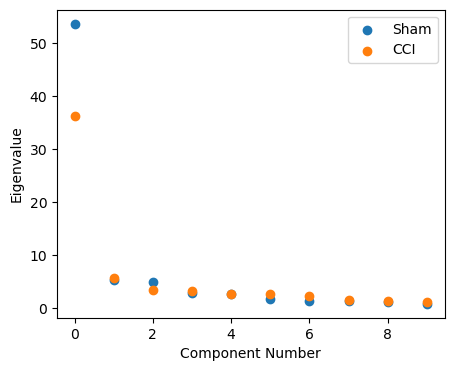

In [28]:
# Compute correlation matrix for each rat, average matrices, then produce gradient

# this is resting state
folder_path = '/Users/rachelfox/dFC_Toolboxes/Leida/CSVs_with_regions_stim_pattern_CIMT/Restingstate'

# List to store dataframes
dfs_SHM = []
dfs_CCI = []

day = "07d" # change for 07d, 21d and 49d

# Loop through files in the folder, get time series, and compute correlation matrix
for file_name in os.listdir(folder_path):
    if 'SHM' in file_name and day in file_name and file_name.endswith('.csv'):
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path, header=None)

        SHM_ts = (df.T).values
        correlation_measure = ConnectivityMeasure(kind='correlation')
        correlation_matrix = correlation_measure.fit_transform([SHM_ts.T])[0]

        dfs_SHM.append(correlation_matrix)
    elif 'CCI' in file_name and day in file_name and file_name.endswith('.csv'):
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path, header=None)

        CCI_ts = (df.T).values
        correlation_measure = ConnectivityMeasure(kind='correlation')
        correlation_matrix = correlation_measure.fit_transform([CCI_ts.T])[0]

        dfs_CCI.append(correlation_matrix)

# calculate average correlation matrix
stacked_arrays = np.stack(dfs_CCI, axis=0)
correlation_matrix_CCI = np.mean(stacked_arrays, axis=0)

stacked_arrays_s = np.stack(dfs_SHM, axis=0)
correlation_matrix_SHM = np.mean(stacked_arrays_s, axis=0)

# compute gradients for each group
gm_SHM = GradientMaps(n_components=10, kernel='pearson', approach='dm', random_state=0)
gm_SHM.fit(correlation_matrix_SHM)

gm_CCI = GradientMaps(n_components=10, kernel='pearson', approach='dm', random_state=0)
gm_CCI.fit(correlation_matrix_CCI)

# graph eigenvalues
fig, ax = plt.subplots(1, figsize=(5, 4))
ax.scatter(range(gm_SHM.lambdas_.size), gm_SHM.lambdas_, label="Sham")
ax.scatter(range(gm_CCI.lambdas_.size), gm_CCI.lambdas_, label="CCI")
ax.set_xlabel('Component Number')
ax.set_ylabel('Eigenvalue')
ax.legend()

# shows the amount of variance explained using eigenvalues
print("Eigenvalues CCI")
print(np.cumsum(gm_CCI.lambdas_) / np.sum(gm_CCI.lambdas_)) 

print("Eigenvalues Sham")
print(np.cumsum(gm_SHM.lambdas_) / np.sum(gm_SHM.lambdas_))

# save files
#filename = f"CCIgradrest_{day}_corrmatrixAverage.csv"
#with open(filename, mode='w', newline='') as file:
#    writer = csv.writer(file)
 #   writer.writerows(gm_CCI.gradients_)

#filename = f"SHMgradrest_{day}_corrmatrixAverage.csv"
#with open(filename, mode='w', newline='') as file:
#    writer = csv.writer(file)
#    writer.writerows(gm_SHM.gradients_)

/Users/rachelfox/opt/anaconda3/lib/python3.9/site-packages/nilearn/connectome/connectivity_matrices.py:509: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  covariances_std = [
/Users/rachelfox/opt/anaconda3/lib/python3.9/site-packages/nilearn/connectome/connectivity_matrices.py:509: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  covariances_

Eigenvalues CCI
[0.58879849 0.70212502 0.77519296 0.82842518 0.87216914 0.90668338
 0.93609013 0.96050519 0.98194355 1.        ]
Eigenvalues Sham
[0.82547376 0.89467533 0.92141666 0.94153479 0.95595297 0.96762275
 0.97739228 0.98598209 0.99331715 1.        ]


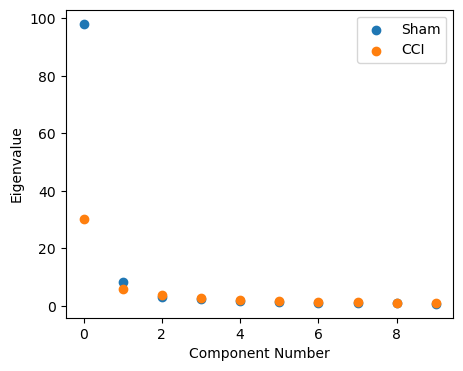

In [31]:
# individual gradients for each rat
folder_path = '/Users/rachelfox/dFC_Toolboxes/Leida/CSVs_with_regions_stim_pattern_CIMT/Restingstate'

# List to store dataframes
dfs_SHM = []
dfs_CCI = []

day = "07d" # change for 07d, 21d and 49d -- run this cell/cells above for each day prior to running below cells

# Loop through files in the folder, get time series, correlation matrix, and gradient for each rat
for file_name in os.listdir(folder_path):
   if 'SHM' in file_name and day in file_name and file_name.endswith('.csv'):
      file_path = os.path.join(folder_path, file_name)
      df = pd.read_csv(file_path, header=None)

      SHM_ts = (df.T).values
      correlation_measure = ConnectivityMeasure(kind='correlation')
      correlation_matrix_SHM = correlation_measure.fit_transform([SHM_ts.T])[0]

      gm_SHM = GradientMaps(n_components=10, kernel='pearson', approach='dm', random_state=0)
      gm_SHM.fit(correlation_matrix_SHM)

      dfs_SHM.append(gm_SHM)

   elif 'CCI' in file_name and day in file_name and file_name.endswith('.csv'):
      file_path = os.path.join(folder_path, file_name)
      df = pd.read_csv(file_path, header=None)

      CCI_ts = (df.T).values
      correlation_measure = ConnectivityMeasure(kind='correlation')
      correlation_matrix_CCI = correlation_measure.fit_transform([CCI_ts.T])[0]

      gm_CCI = GradientMaps(n_components=10, kernel='pearson', approach='dm', random_state=0)
      gm_CCI.fit(correlation_matrix_CCI)

      dfs_CCI.append(gm_CCI)

# average the gradients for CCI and Sham
gradients_CCI = [gm.gradients_ for gm in dfs_CCI]
gradients_stack_CCI = np.stack(gradients_CCI, axis=0)
average_gradients_CCI = np.mean(gradients_stack_CCI, axis=0)
gm_CCI = GradientMaps()
gm_CCI.gradients_ = average_gradients_CCI
gm_CCI.lambdas_ = np.mean([gm.lambdas_ for gm in dfs_CCI], axis=0)

gradients_SHM = [gm.gradients_ for gm in dfs_SHM]
gradients_stack_SHM = np.stack(gradients_SHM, axis=0)
average_gradients_SHM = np.mean(gradients_stack_SHM, axis=0)
gm_SHM = GradientMaps()
gm_SHM.gradients_ = average_gradients_SHM
gm_SHM.lambdas_ = np.mean([gm.lambdas_ for gm in dfs_SHM], axis=0)

# graph eigenvalues
fig, ax = plt.subplots(1, figsize=(5, 4))
ax.scatter(range(gm_SHM.lambdas_.size), gm_SHM.lambdas_, label="Sham")
ax.scatter(range(gm_CCI.lambdas_.size), gm_CCI.lambdas_, label="CCI")
ax.set_xlabel('Component Number')
ax.set_ylabel('Eigenvalue')
ax.legend()

# shows the amount of variance explained using eigenvalues
print("Eigenvalues CCI")
print(np.cumsum(gm_CCI.lambdas_) / np.sum(gm_CCI.lambdas_)) 

print("Eigenvalues Sham")
print(np.cumsum(gm_SHM.lambdas_) / np.sum(gm_SHM.lambdas_))

# save files
#filename = f"CCIgradrest_{day}_gradientAverage.csv"
#with open(filename, mode='w', newline='') as file:
#    writer = csv.writer(file)
 #   writer.writerows(gm_CCI.gradients_)

#filename = f"SHMgradrest_{day}_gradientAverage.csv"
#with open(filename, mode='w', newline='') as file:
#    writer = csv.writer(file)
#    writer.writerows(gm_SHM.gradients_)

[-44.5389884114353, -44.69081718074188, -42.142302813826944, -45.87725251256726, -46.1070974586548, -44.201106437225285, 64.21604351905117, -44.361110684052484, -43.11807756132542, -41.83045928807596, -1.43610875587148, -45.19614219587304, 65.7922411186127, 63.803448432642604, 64.96563352742172, -34.10310746595607, 24.6276035015579, 66.31013751333288, -45.62063186379814, -8.518396674092383, -44.221634450073985, -46.15510739739934, 59.92400933503587, -43.38113199191622, 63.17193286097264, 23.483934067195364, 62.83242847132778, 16.832210007144322, 20.491524092572202, -39.015099833628014, -23.692368985665752, 17.406720115761537, -44.00869965244104, -44.142708113940685, 29.629068576403938, -42.29887275004701, 63.980681722385484, -39.72179557065496, 63.80576686993062, 66.62749056061136, 64.6980143999316, 68.43936684190278, 63.00280994373023, 67.7826503480351, 64.65617870268142, 68.08070699331472, 64.59304424120975, 69.58236752640744, 65.64518644768359, 67.85276779629615, 64.635312681573, 57

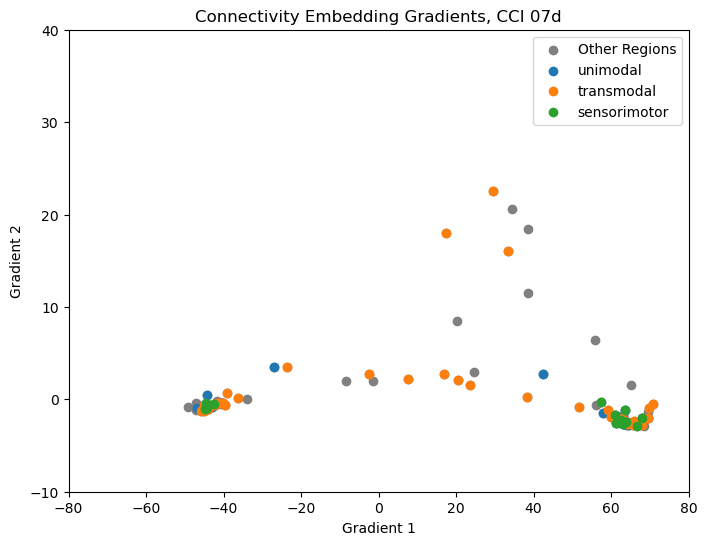

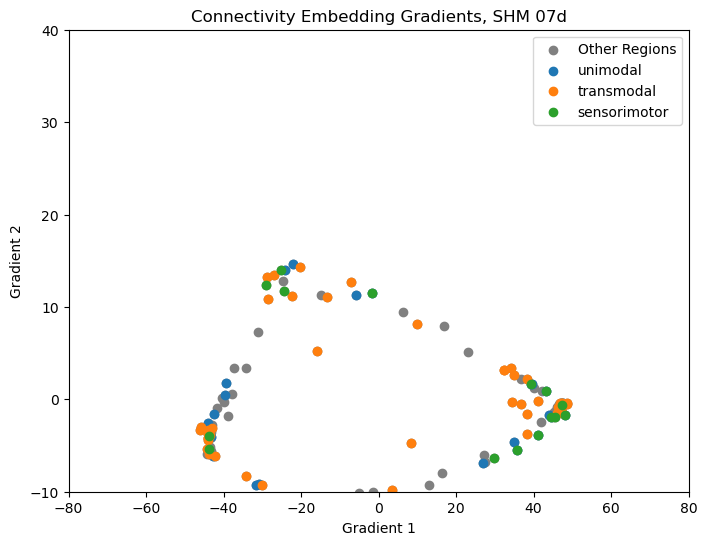

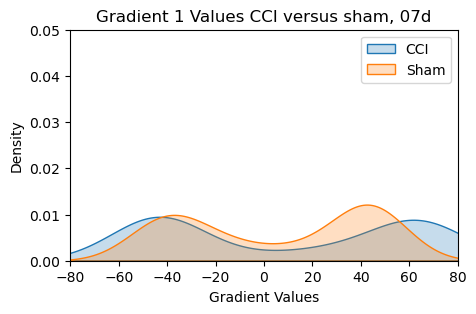

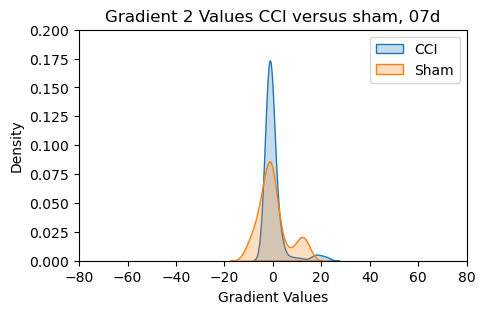

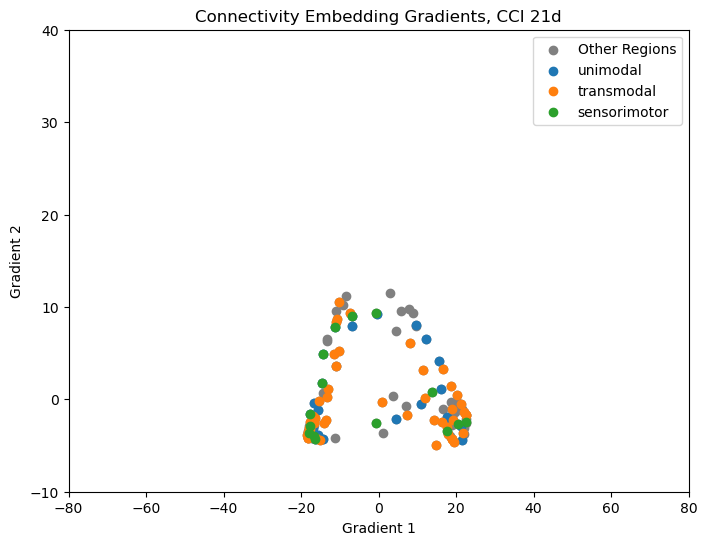

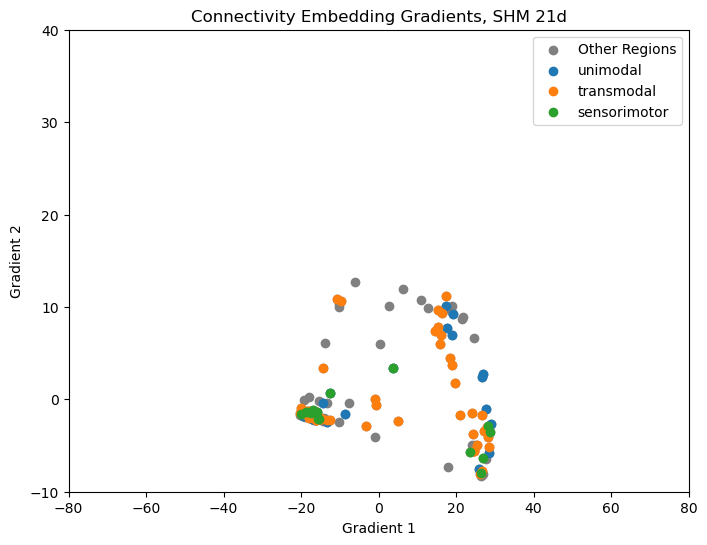

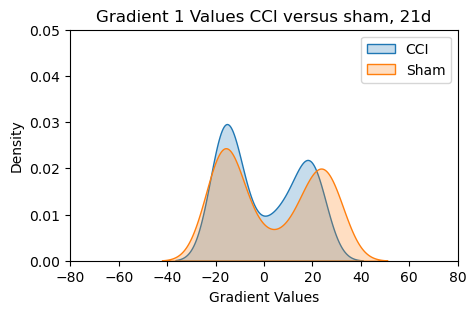

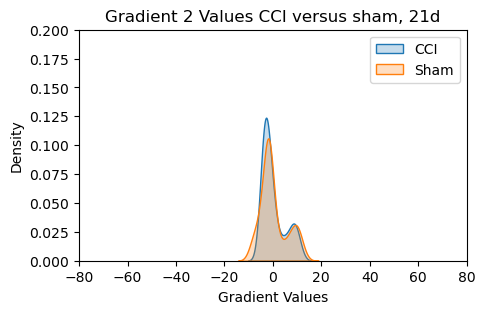

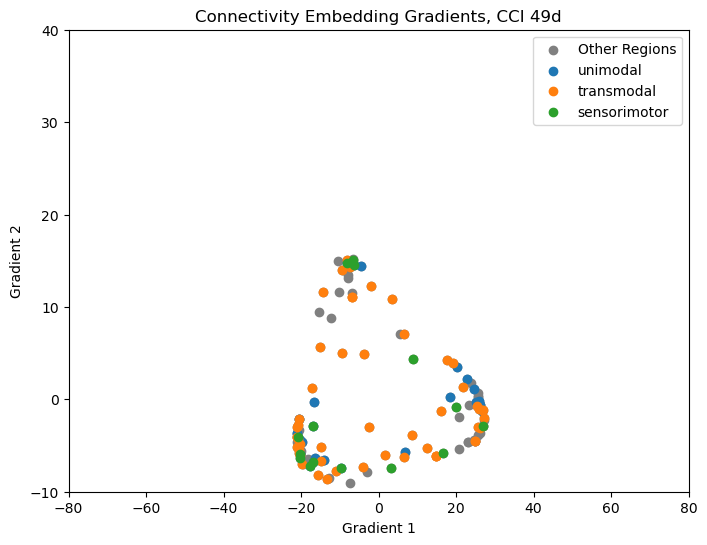

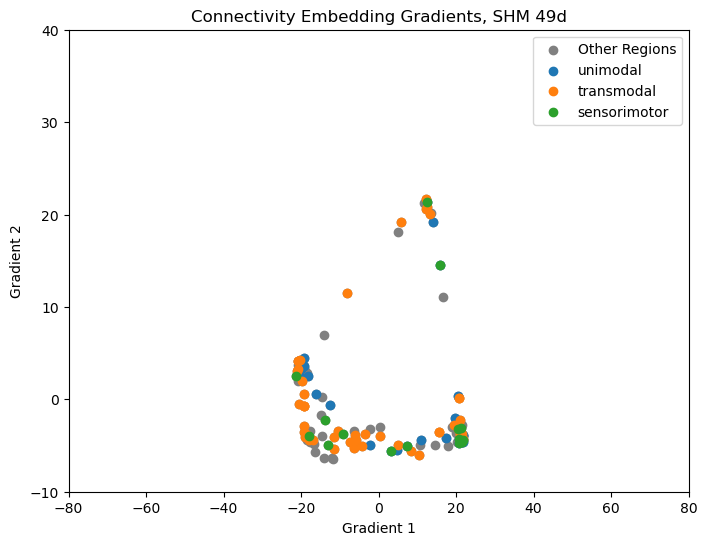

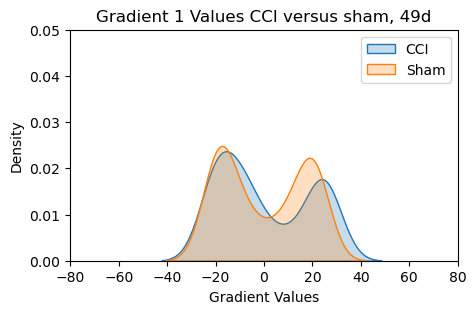

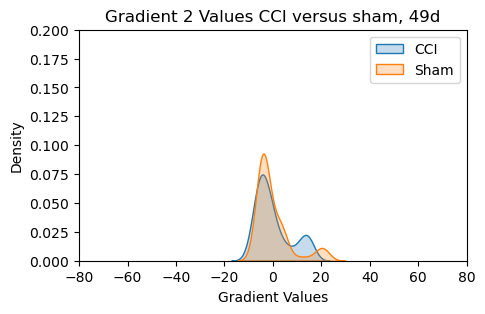

In [32]:
# graph the gradients

# networks for dividing gradient scores
region_categories = {
   #yeo networks are visual, somatomotor, dosralattention, salientventralattention, control, limbic, default - figure out which of our ROIs are involved in each of these
   'unimodal': [67, 68, 69, 70, 71, 72, 73, 74, 7, 8, 9, 50, 51, 52, 53, 54, 55, 56, 57, 58, 112, 113, 114, 115, 116, 117],
   'transmodal': [6, 77, 12, 80, 13, 81, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 37, 86, 38, 103, 43, 106, 46, 79, 108, 109, 110, 111, 47, 48, 49, 62, 106, 63, 121, 64, 106, 124],
   'sensorimotor': [39, 40, 50, 54, 58, 65, 66, 104, 105, 112, 114, 115, 117, 122, 123]
}

# import files
days = ["07d","21d","49d"]
CCI_1 = []
SHM_1 = []
CCI_2 = []
SHM_2 = []

extension = "gradientAverage" # change to corrmatrixAverage or tsAverage depending on method to get gradient

# loop through for each day
for day in days:

    # get the gradient for that day
    gmCCI = np.loadtxt(f"CCIgradrest_{day}_{extension}.csv", delimiter=',')
    gmSHM = np.loadtxt(f"SHMgradrest_{day}_{extension}.csv", delimiter=',')
    
    # get primary and secondary gradients
    gradient1CCI = gmCCI[:, 0] 
    print(gradient1CCI.tolist())
    gradient2CCI = gmCCI[:, 1]
    CCI_1.append(gradient1CCI)
    CCI_2.append(gradient2CCI)

    gradient1SHM = gmSHM[:, 0]
    gradient2SHM = gmSHM[:, 1]
    SHM_1.append(gradient1SHM)
    SHM_2.append(gradient2SHM)

    # graph scatter plot of CCI gradient 1 and 2, use networks to separate ROIs
    plt.figure(figsize=(8, 6))
    plt.scatter(gradient1CCI, gradient2CCI, c='gray', label='Other Regions')
    for category, indices in region_categories.items():
        print(np.array(indices)-1)
        adjusted_indices = np.array(indices)-1
        plt.scatter(gradient1CCI[adjusted_indices], gradient2CCI[adjusted_indices], label=category)
    plt.xlabel('Gradient 1')
    plt.ylabel('Gradient 2')
    plt.xlim(-80, 80)
    plt.ylim(-10, 40)
    plt.title(f'Connectivity Embedding Gradients, CCI {day}')
    plt.legend()

    # graph scatter plot of Sham gradient 1 and 2, use networks to separate ROIs
    plt.figure(figsize=(8, 6))
    plt.scatter(gradient1SHM, gradient2SHM, c='gray', label='Other Regions')
    for category, indices in region_categories.items():
        adjusted_indices = np.array(indices)-1
        plt.scatter(gradient1SHM[adjusted_indices], gradient2SHM[adjusted_indices], label=category)
    plt.xlabel('Gradient 1')
    plt.ylabel('Gradient 2')
    plt.xlim(-80, 80)
    plt.ylim(-10, 40)
    plt.title(f'Connectivity Embedding Gradients, SHM {day}')
    plt.legend()

    # graph density plots between CCI and sham at each time point for gradients 1 and 2
    plt.figure(figsize=(5, 3))
    sns.kdeplot((gradient1CCI), shade=True, label="CCI")
    sns.kdeplot((gradient1SHM), shade=True, label="Sham")
    plt.xlabel('Gradient Values')
    plt.ylabel('Density')
    plt.xlim(-80, 80)
    plt.ylim(0, 0.05)
    plt.title(f'Gradient 1 Values CCI versus sham, {day}')
    plt.legend()
    variance_CCI = np.var(gradient1CCI)
    variance_SHM = np.var(gradient1SHM)
    print(f'Principal gradient variance CCI {variance_CCI} Sham {variance_SHM}')

    plt.figure(figsize=(5, 3))
    sns.kdeplot((gradient2CCI), shade=True, label="CCI")
    sns.kdeplot((gradient2SHM), shade=True, label="Sham")
    plt.xlabel('Gradient Values')
    plt.ylabel('Density')
    plt.xlim(-80, 80)
    plt.ylim(0, 0.2)
    plt.title(f'Gradient 2 Values CCI versus sham, {day}')
    plt.legend()

In [34]:
# statistics for gradients

# Mann-Whitney test to see in nonparametric distribution if group means are different
sensorimotor = [39, 40, 50, 54, 58, 65, 66, 104, 105, 112, 114, 115, 117, 122, 123] # specific sensorimotor ROIs to analyze further
for i in [0, 1, 2]:
    u_statistic, p_value = mannwhitneyu(abs(CCI_1[i][sensorimotor]), abs(SHM_1[i][sensorimotor]))
    print(f"Mann Whitney Test for timepoint {i}: {u_statistic}, {p_value}")

# ANOVA to see effect of group/time on gradient score
gradient_scores = [CCI_1[0], CCI_1[1], CCI_1[2], SHM_1[0], SHM_1[1], SHM_1[2]] #CCI_1/SHM_1 are primary gradients from previous cell, [0, 1, 2] are 7, 21, 49d
cohort_labels = np.repeat([1, 2], 3)
timepoints = np.repeat(["7", "21", "49", "7", "21", "49"], 124)

df = pd.DataFrame({
    'Gradient_Score': np.concatenate(gradient_scores),
    'Group': np.repeat(['CCI', 'CCI', 'CCI', 'SHM', 'SHM', 'SHM'], 124),
    'Day': timepoints
})

df['Day'] = pd.Categorical(df['Day'], categories=['7', '21', '49'])

model = ols('Gradient_Score ~ C(Group) * C(Day)', data=df).fit()
anova_table = anova_lm(model)
print(anova_table)

Mann Whitney Test for timepoint 0: 175.0, 0.010121802247772722
Mann Whitney Test for timepoint 1: 91.0, 0.38373262766250305
Mann Whitney Test for timepoint 2: 115.0, 0.9338864180775845
                    df         sum_sq      mean_sq         F    PR(>F)
C(Group)           1.0      29.271772    29.271772  0.033474  0.854880
C(Day)             2.0    7171.498595  3585.749297  4.100567  0.016942
C(Group):C(Day)    2.0    1450.408797   725.204399  0.829324  0.436750
Residual         738.0  645345.698939   874.452167       NaN       NaN


In [ ]:
# Project the gradients onto the brain surface --> output nii files to then use in fsleyes/mrview

# Load the nifti file
labels_file_r = '/Users/rachelfox/dFC_Toolboxes/UpdatedLabels/left_labels_add200.nii'
labels_img_r = nib.load(labels_file_r)
labels_file_l = '/Users/rachelfox/dFC_Toolboxes/UpdatedLabels/right_labels_add199.nii'
labels_img_l = nib.load(labels_file_l)

labels_data_r = labels_img_r.get_fdata()
labels_data_l = labels_img_l.get_fdata()

# make 0 vector same length as flattened nifti for gradient scores as interpolation values
# Change filenames for specific gradient
gradient1CCI = np.loadtxt("CCIgradrest_49d_v2.csv", delimiter=',')
gradient1SHM = np.loadtxt("SHMgradrest_49d_v2.csv", delimiter=',')

inputarray = gradient1CCI[:, 0] # change for sham
filename_r = "CCIRH_grad1_49d_v2.nii" # for final output of gradient
filename_l = "CCILH_grad1_49d_v2.nii"

gradientnifti_l = np.zeros(labels_data_l.flatten().shape) # for the actual stuff in the file
gradientnifti_r = np.zeros(labels_data_l.flatten().shape)

# flatten the labels to get the same shape
lhlabelsnifti = np.array(labels_data_l.flatten())
rhlabelsnifti = np.array(labels_data_r.flatten())

# replace all of the interpolation values with the gradient score at the applicable index
for i in range(1, len(lhlabelsnifti)):
   interpvalue = lhlabelsnifti[i]
   if interpvalue != 0 and interpvalue != 199 and interpvalue != 200:
      gradientnifti_l[i] = inputarray[int(interpvalue)-1]
   if interpvalue == 199 or interpvalue == 200:
      gradientnifti_l[i] = 0
   if interpvalue == 0:
      gradientnifti_l[i] = -100

for i in range(1, len(rhlabelsnifti)):
   interpvalue = rhlabelsnifti[i]
   if interpvalue != 0 and interpvalue != 199 and interpvalue != 200:
      gradientnifti_r[i] = inputarray[int(interpvalue)-1]
   if interpvalue == 199 or interpvalue == 200:
      gradientnifti_r[i] = 0
   if interpvalue == 0:
      gradientnifti_r[i] = -100

# save as nii file (write nifti)
origshape_l = labels_data_l.shape
reshaped_l = gradientnifti_l.reshape(origshape_l)
nifti_img_l = nib.Nifti1Image(reshaped_l, affine=np.eye(4))
nib.save(nifti_img_l, filename_l) # uncomment for making new grad file

origshape_r = labels_data_r.shape
reshaped_r = gradientnifti_r.reshape(origshape_r)
nifti_img_r = nib.Nifti1Image(reshaped_r, affine=np.eye(4))
nib.save(nifti_img_r, filename_r) # uncomment for making new grad file
